In [0]:
import warnings 
warnings.filterwarnings('ignore')

## K-Nearest-Neighbors

KNN falls in the supervised learning family of algorithms. Informally, this means that we are given a labelled dataset consiting of training observations (x,y) and would like to capture the relationship between x and y. More formally, our goal is to learn a function h:X→Y so that given an unseen observation x, h(x) can confidently predict the corresponding output y.

In this module we will explore the inner workings of KNN, choosing the optimal K values and using KNN from scikit-learn.

## Overview

1.Read the problem statement.

2.Get the dataset.

3.Explore the dataset.

4.Pre-processing of dataset.

5.Visualization

6.Transform the dataset for building machine learning model.

7.Split data into train, test set.

7.Build Model.

8.Apply the model.

9.Evaluate the model.

10.Finding Optimal K value

11.Repeat 7,8,9 steps.

## Problem statement

### Dataset

The data set we’ll be using is the Iris Flower Dataset which was first introduced in 1936 by the famous statistician Ronald Fisher and consists of 50 observations from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor). Four features were measured from each sample: the length and the width of the sepals and petals.

**Attributes of the dataset:** https://archive.ics.uci.edu/ml/datasets/Iris

**Train the KNN algorithm to be able to distinguish the species from one another given the measurements of the 4 features.**

## Question 1

Import the data set and print 10 random rows from the data set

In [19]:
#Import all the necessary modules
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
# importing ploting libraries
import matplotlib.pyplot as plt   
#importing seaborn for statistical plots
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [63]:
# calculate accuracy measures and confusion matrix
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc

In [163]:
# Since it is a data file with no header, we will supply the column names which have been obtained from the above URL 
# Create a python list of column names called "names"
colnames = ['sepal length in cm', 'sepal width in cm', 'petal length in cm', 'petal width in cm', 'class']

#Load the file from local directory using pd.read_csv which is a special form of read_table
#while reading the data, supply the "colnames" list
iris_df = pd.read_csv("iris.data", names= colnames)

In [31]:
print(iris_df.head(10))

   sepal length in cm  sepal width in cm  petal length in cm  \
0                 5.1                3.5                 1.4   
1                 4.9                3.0                 1.4   
2                 4.7                3.2                 1.3   
3                 4.6                3.1                 1.5   
4                 5.0                3.6                 1.4   
5                 5.4                3.9                 1.7   
6                 4.6                3.4                 1.4   
7                 5.0                3.4                 1.5   
8                 4.4                2.9                 1.4   
9                 4.9                3.1                 1.5   

   petal width in cm        class  
0                0.2  Iris-setosa  
1                0.2  Iris-setosa  
2                0.2  Iris-setosa  
3                0.2  Iris-setosa  
4                0.2  Iris-setosa  
5                0.4  Iris-setosa  
6                0.3  Iris-setosa  
7      

## Data Pre-processing

## Question 2 - Estimating missing values

*Its not good to remove the records having missing values all the time. We may end up loosing some data points. So, we will have to see how to replace those missing values with some estimated values (median) *

In [32]:
#check for missing values along the columns
print(iris_df.isnull().sum(axis = 0))
#check for missing values along the rows
print(iris_df.isnull().sum(axis = 1))
# Shows there are no missing values along the data

sepal length in cm    0
sepal width in cm     0
petal length in cm    0
petal width in cm     0
class                 0
dtype: int64
0      0
1      0
2      0
3      0
4      0
5      0
6      0
7      0
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     0
20     0
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     0
29     0
      ..
120    0
121    0
122    0
123    0
124    0
125    0
126    0
127    0
128    0
129    0
130    0
131    0
132    0
133    0
134    0
135    0
136    0
137    0
138    0
139    0
140    0
141    0
142    0
143    0
144    0
145    0
146    0
147    0
148    0
149    0
Length: 150, dtype: int64


In [33]:
iris_df['sepal length in cm']= iris_df['sepal length in cm'].replace(0,iris_df['sepal length in cm'].median())
iris_df['sepal width in cm']= iris_df['sepal width in cm'].replace(0,iris_df['sepal width in cm'].median())
iris_df['petal length in cm']= iris_df['petal length in cm'].replace(0,iris_df['petal length in cm'].median())
iris_df['petal width in cm']= iris_df['petal width in cm'].replace(0,iris_df['petal width in cm'].median())

In [34]:
print(iris_df.head(10))

   sepal length in cm  sepal width in cm  petal length in cm  \
0                 5.1                3.5                 1.4   
1                 4.9                3.0                 1.4   
2                 4.7                3.2                 1.3   
3                 4.6                3.1                 1.5   
4                 5.0                3.6                 1.4   
5                 5.4                3.9                 1.7   
6                 4.6                3.4                 1.4   
7                 5.0                3.4                 1.5   
8                 4.4                2.9                 1.4   
9                 4.9                3.1                 1.5   

   petal width in cm        class  
0                0.2  Iris-setosa  
1                0.2  Iris-setosa  
2                0.2  Iris-setosa  
3                0.2  Iris-setosa  
4                0.2  Iris-setosa  
5                0.4  Iris-setosa  
6                0.3  Iris-setosa  
7      

## Question 3 - Dealing with categorical data

Change all the classes to numericals (0to2).

In [35]:
from sklearn.preprocessing import LabelEncoder

lb_make = LabelEncoder()
iris_df["class"] = lb_make.fit_transform(iris_df["class"])
iris_df.tail(100)

,sepal length in cm,sepal width in cm,petal length in cm,petal width in cm,class
50,7.0,3.2,4.7,1.4,1
51,6.4,3.2,4.5,1.5,1
52,6.9,3.1,4.9,1.5,1
53,5.5,2.3,4.0,1.3,1
54,6.5,2.8,4.6,1.5,1
55,5.7,2.8,4.5,1.3,1
56,6.3,3.3,4.7,1.6,1
57,4.9,2.4,3.3,1.0,1
58,6.6,2.9,4.6,1.3,1
59,5.2,2.7,3.9,1.4,1


## Question 4

*Observe the association of each independent variable with target variable and drop variables from feature set having correlation in range -0.1 to 0.1 with target variable.*

In [43]:
iris_df.describe().T
print(iris_df.corr())
print("As none of the variables have the co-releation between -0.1 and 0.1 with the class Variable hence no variables have been dropped")

                    sepal length in cm  sepal width in cm  petal length in cm  \
sepal length in cm            1.000000          -0.109369            0.871754   
sepal width in cm            -0.109369           1.000000           -0.420516   
petal length in cm            0.871754          -0.420516            1.000000   
petal width in cm             0.817954          -0.356544            0.962757   
class                         0.782561          -0.419446            0.949043   

                    petal width in cm     class  
sepal length in cm           0.817954  0.782561  
sepal width in cm           -0.356544 -0.419446  
petal length in cm           0.962757  0.949043  
petal width in cm            1.000000  0.956464  
class                        0.956464  1.000000  
As none of the variables have the co-releation between -0.1 and 0.1 with the class Variable hence no variables have been dropped


## Question 5

*Observe the independent variables variance and drop such variables having no variance or almost zero variance(variance < 0.1). They will be having almost no influence on the classification.*

In [44]:
print(iris_df.var())
print("As none of the variables have variance less than 0.1 hence no variables have been dropped")

sepal length in cm    0.685694
sepal width in cm     0.188004
petal length in cm    3.113179
petal width in cm     0.582414
class                 0.671141
dtype: float64
As none of the variables have variance less than 0.1 hence no variables have been dropped


## Question 6

*Plot the scatter matrix for all the variables.*

C:\Users\sush\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


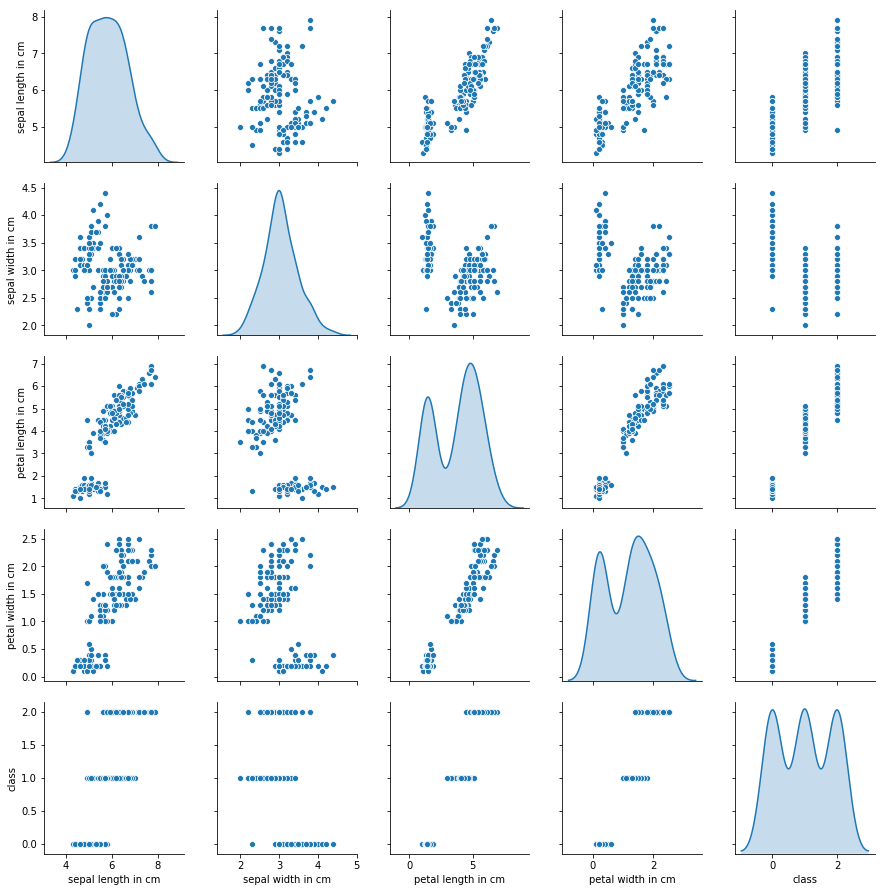

In [46]:
sns.pairplot( iris_df , diag_kind='kde')

## Split the dataset into training and test sets

## Question 7

*Split the dataset into training and test sets with 80-20 ratio.*

In [53]:
from sklearn.model_selection import train_test_split
from scipy.stats import zscore

In [54]:
X = iris_df.drop("class", axis=1)
X = X.apply(zscore)   #Convert to Z score
y = iris_df["class"]

In [55]:
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

## Question 8 - Model

*Build the model and train and test on training and test sets respectively using **scikit-learn**. Print the Accuracy of the model with different values of **k=3,5,9**.*

**Hint:** For accuracy you can check **accuracy_score()** in scikit-learn

In [56]:
from sklearn.neighbors import KNeighborsClassifier

In [70]:
#K = 3
NNH = KNeighborsClassifier(n_neighbors= 3) # setting the base model 
# Call Nearest Neighbour algorithm
NNH.fit(X_train, y_train)
predicted_labels1 = NNH.predict(X_test)
predicted_labels2 = NNH.predict(X_train)
print("the accuracy of KNN Model with K value 3 on Test Data : ",
      pd.DataFrame(data=[accuracy_score(y_test, predicted_labels1)], 
             index=["accuracy"])) 
print("the accuracy of KNN Model with K value 3 on Train Data : ",
      pd.DataFrame(data=[accuracy_score(y_train, predicted_labels2)], 
             index=["accuracy"]))   

the accuracy of KNN Model with K value 3 on Test Data :                   0
accuracy  0.866667
the accuracy of KNN Model with K value 3 on Train Data :                0
accuracy  0.975


In [71]:
#K = 5
NNH = KNeighborsClassifier(n_neighbors= 5) # setting the base model 
# Call Nearest Neighbour algorithm
NNH.fit(X_train, y_train)
predicted_labels1 = NNH.predict(X_test)
predicted_labels2 = NNH.predict(X_train)
print("the accuracy of KNN Model with K value 5 on Test Data : ",
      pd.DataFrame(data=[accuracy_score(y_test, predicted_labels1)], 
             index=["accuracy"])) 
print("the accuracy of KNN Model with K value 5 on Train Data : ",
      pd.DataFrame(data=[accuracy_score(y_train, predicted_labels2)], 
             index=["accuracy"]))   

the accuracy of KNN Model with K value 5 on Test Data :              0
accuracy  0.9
the accuracy of KNN Model with K value 5 on Train Data :                0
accuracy  0.975


In [72]:
#K = 9
NNH = KNeighborsClassifier(n_neighbors= 9) # setting the base model 
# Call Nearest Neighbour algorithm
NNH.fit(X_train, y_train)
predicted_labels1 = NNH.predict(X_test)
predicted_labels2 = NNH.predict(X_train)
print("the accuracy of KNN Model with K value 9 on Test Data : ",
      pd.DataFrame(data=[accuracy_score(y_test, predicted_labels1)], 
             index=["accuracy"])) 
print("the accuracy of KNN Model with K value 9 on Train Data : ",
      pd.DataFrame(data=[accuracy_score(y_train, predicted_labels2)], 
             index=["accuracy"]))   

the accuracy of KNN Model with K value 9 on Test Data :              0
accuracy  0.9
the accuracy of KNN Model with K value 9 on Train Data :                0
accuracy  0.975


## Question 9 - Cross Validation

Run the KNN with no of neighbours to be 1,3,5..19 and *Find the **optimal number of neighbours** from the above list using the Mis classification error

Hint:

Misclassification error (MSE) = 1 - Test accuracy score. Calculated MSE for each model with neighbours = 1,3,5...19 and find the model with lowest MSE

In [133]:
K_neigh = [ 1,3,5,7,9,11,13,15,17,19]
TestResults = []
for i in K_neigh:
    NNH = KNeighborsClassifier(n_neighbors= i)
    NNH.fit(X_train, y_train)
    predicted_labels1 = NNH.predict(X_test)
    predicted_labels2 = NNH.predict(X_train)
    testAccuracy = accuracy_score(y_test, predicted_labels1)
    testMSE = 1 - testAccuracy
    TestResults.append({'Neighbour': i, 'Accuracy': testAccuracy, 'MSE':
    testMSE})
TestResultsNew = pd.DataFrame(TestResults)
print(TestResultsNew)
print("the KNN with Neighbour 7 and MSE 0.066667 is the optimal solution ")

   Accuracy       MSE  Neighbour
0  0.900000  0.100000          1
1  0.866667  0.133333          3
2  0.900000  0.100000          5
3  0.933333  0.066667          7
4  0.900000  0.100000          9
5  0.900000  0.100000         11
6  0.866667  0.133333         13
7  0.866667  0.133333         15
8  0.866667  0.133333         17
9  0.866667  0.133333         19
the KNN with Neighbour 7 and MSE 0.066667 is the optimal solution 


## Question 10

*Plot misclassification error vs k (with k value on X-axis) using matplotlib.*

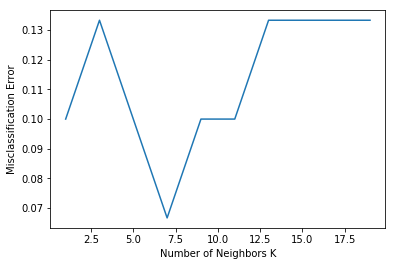

In [135]:
plt.plot(TestResultsNew["Neighbour"], TestResultsNew["MSE"])
plt.xlabel('Number of Neighbors K')
plt.ylabel('Misclassification Error')
plt.show()

# Naive Bayes with Iris Data

In [136]:
#Load all required library
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

### Slice  Iris data set for Independent variables and dependent variables
#### Please note 'Species' is my dependent variables, name it y and independent set data as X

In [0]:
#Check the dataset
print(y)
print(X)

# Question 11 
Find the distribution of target variable (Class)

And, Plot the distribution of target variable using histogram

(array([50.,  0.,  0.,  0.,  0., 50.,  0.,  0.,  0., 50.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <a list of 10 Patch objects>)

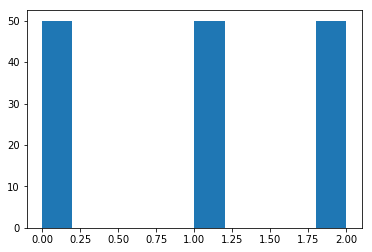

In [137]:
plt.hist(iris_df['class'])

In [0]:
#Drop Id variable from data

### Question 12 
Find Correlation among all variables and give your insights 

In [0]:
#Please note, it's Require to remove correlated features because they are voted twice in the model and 
## it can lead to over inflating importance.We will ignore it here

In [143]:
print(iris_df.corr())
print("Petal length and width have a strong positive linear relationship with the class variable ")
print("sepal width has least co-relation with the class variable ")

                    sepal length in cm  sepal width in cm  petal length in cm  \
sepal length in cm            1.000000          -0.109369            0.871754   
sepal width in cm            -0.109369           1.000000           -0.420516   
petal length in cm            0.871754          -0.420516            1.000000   
petal width in cm             0.817954          -0.356544            0.962757   
class                         0.782561          -0.419446            0.949043   

                    petal width in cm     class  
sepal length in cm           0.817954  0.782561  
sepal width in cm           -0.356544 -0.419446  
petal length in cm           0.962757  0.949043  
petal width in cm            1.000000  0.956464  
class                        0.956464  1.000000  
Petal length and width have a strong positive linear relationship with the class variable 
sepal width has least co-relation with the class variable 


Petal length and width have a strong positive linear relationship with the class variable 
sepal width has least co-relation with the class variable 


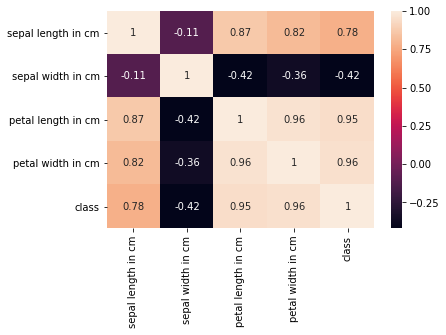

In [141]:
sns.heatmap( iris_df.corr(), annot=True)
print("Petal length and width have a strong positive linear relationship with the class variable ")
print("sepal width has least and negative co-relation with the class variable ")

### Split data in Training and test set in 80:20.

In [184]:
X = iris_df.drop("class", axis=1)
X = X.apply(zscore)   #Convert to Z score
test_size = 0.20 # taking 80:20 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Question 13 
Do Feature Scaling 

In [229]:
# Use StandardScaler or similar methods
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(scaler.fit(X_train, y_train))

StandardScaler(copy=True, with_mean=True, with_std=True)


### Question 14 
Train and Fit NaiveBayes Model

In [185]:
X = pima_df.drop("class", axis=1)
y = pima_df["class"]

In [176]:
test_size = 0.20 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

In [218]:
#Fit the model
model = GaussianNB()
model.fit(X_train, y_train)
print(model)

GaussianNB(priors=None, var_smoothing=1e-09)


In [219]:
#Predict
predicted = model.predict(X_test)

### Question 15 
Print Accuracy and Confusion Matrix and Conclude your findings

In [213]:
# show Confusion Matrix
metrics.confusion_matrix(y_test,predicted)

array([[ 0,  3,  4],
       [ 2, 10,  0],
       [ 2,  9,  0]], dtype=int64)

In [214]:
# show accuracy
model_score = model.score(X_test, y_test)
print(model_score)

0.3333333333333333


In [227]:
#Show precision and Recall metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve,roc_auc_score
pd.DataFrame(data=[accuracy_score(y_test, predicted, average = weighted), 
                   recall_score(y_test, predicted, average = weighted),
                   precision_score(y_test, predicted , average = weighted),
                   f1_score(y_test, predicted, average = weighted)], 
             index=["accuracy", "recall", "precision", "f1Score"])

NameError: name 'weighted' is not defined

# For Practice  - Optional

All the questions from 16 to 20 are for practice.

# Using SVM with Diebetes Dataset

In [0]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Question 16 
Read the input file 'Diabetes.csv' using Pandas and check it's column names.

Check dimension of dataset.

Check distribution of dependent variable, Outcome and plot it.


In [0]:
# Eye ball the imported dataset

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [0]:
# Check data types and info of dataset

# Question 17 
Check data distribution using summary statistics and provide your findings.

Do correlation analysis and bivariate viualization with Insights


# Question 18 
Do train and test split. 
Optionally - You can do with stratify sampling(optional) on Outcome variable to maintain the distribution of dependent variable

# Question 19 
Train Support Vector Machine Model(1 Marks)

In [0]:
# use from sklearn.svm import SVC

In [0]:
# your insights

# Question 20
Scale the data points using MinMaxScaler

Fit SVM Model on Scale data and give your observation

#we can try increasing either C or gamma to fit a more complex model.

# Optional Question - 
Try improving the model accuracy using C=1000 (1 Marks)

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [0]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [0]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [0]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [0]:
gs.fit(X_train_scaled, y_train) 

GridSearchCV(cv=10, error_score='raise',
       estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
       fit_params={}, iid=True, n_jobs=4,
       param_grid=[{'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0]}],
       pre_dispatch='2*n_jobs', refit=True, return_train_score=True,
       scoring='accuracy', verbose=0)

In [0]:
gs.best_estimator_

SVC(C=2.5, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape=None, degree=3, gamma='auto', kernel='linear',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [0]:
gs.best_score_ 

0.77777777777777779